Titanic Dataset: The
dataset includes details such as passenger class, age, gender, fare, and
whether they survived the disaster.
Key Features:
PassengerId: Unique identifier for each passenger.
Survived: Survival status (0 = No, 1 = Yes).
Pclass: Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd).
Name: Passenger name.
Sex: Gender of the passenger.
Age: Age of the passenger.
SibSp: Number of siblings/spouses aboard.
Parch: Number of parents/children aboard.
Ticket: Ticket number.
Fare: Fare paid for the ticket.
Cabin: Cabin number.
Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Load the Titanic dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Step 1: Understanding the Dataset

In [6]:
# Check dataset dimensions
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (891, 15)


In [7]:
# Check column types and missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


Step 2: Handling Missing Data

Identify and handle missing values in the dataset

In [8]:
# Check for missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
#Handle missing values
# Fill missing age with median
df['age'].fillna(df['age'].median(), inplace=True) 

In [11]:
# Fill missing embarked with mode
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

In [13]:
# Drop 'deck' column due to excessive missing values
df.drop('deck', axis=1, inplace=True)

In [14]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

Step 3: Analyzing Survival Rates

Explore the overall survival rate and how it varies across different features.

In [15]:
# Overall survival rate
survival_rate = df['survived'].mean() 
print(f"Overall Survival Rate:{survival_rate:.2%}")

Overall Survival Rate:38.38%


In [16]:
# Survival rate by gender
gender_survival = df.groupby('sex')['survived'].mean()
print(gender_survival)

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


In [17]:
# Survival rate by passenger class
class_survival = df.groupby('pclass')['survived'].mean()
print(class_survival)

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


Step 4: Visualizing Key Features

Create visualizations to understand the distribution of key features and their
relationship with survival.

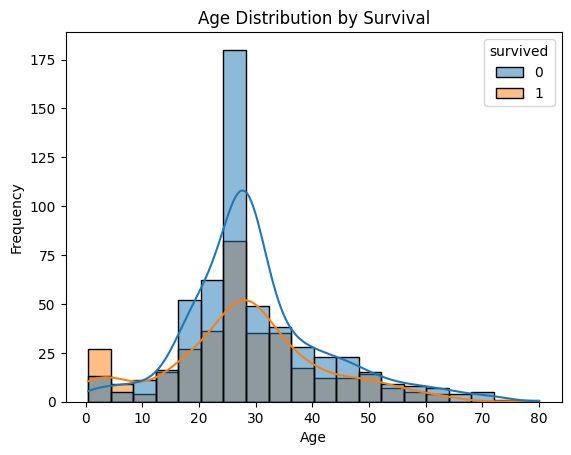

In [18]:
# Age distribution by survival
sns.histplot(data=df, x='age',hue='survived', kde=True, bins=20) 
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

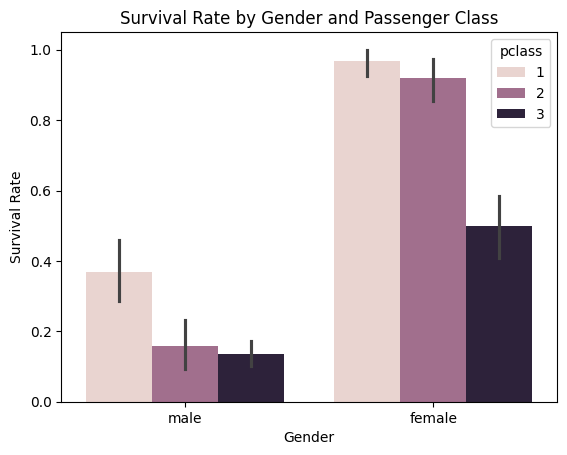

In [19]:
# Survival by gender and class
sns.barplot(x='sex', y='survived',hue='pclass', data=df) 
plt.title('Survival Rate by Gender and Passenger Class') 
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

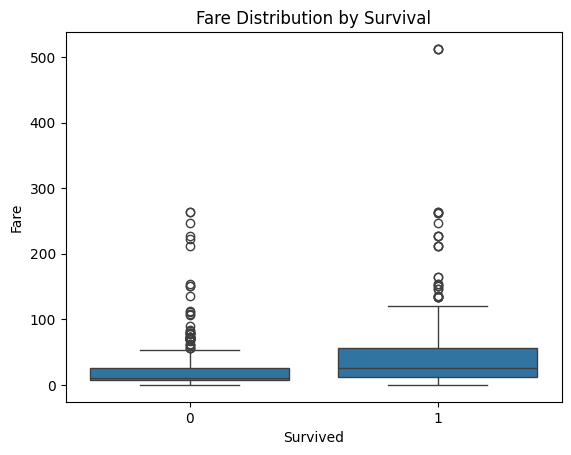

In [20]:
# Fare distribution by survival
sns.boxplot(x='survived', y='fare',data=df)
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.show()

Step 5: Correlation Analysis

Examine the relationships between numerical features using correlation analysis.

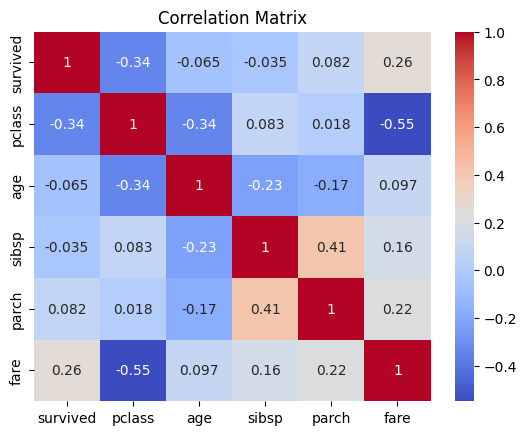

In [24]:
# Correlation matrix
corr = df.select_dtypes(include='number').corr(method='pearson')
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix') 
plt.show()

Deriving Insights and Visual Summaries
Insights from the Data
1. Survival Rate: The overall survival rate was approximately 38%.
2. Gender Impact: Females had a significantly higher survival rate than males.
3. Class Impact: Passengers in higher classes (1st and 2nd) had a higher survival rate compared to those in 3rd class.
4. Age Impact: Children and older passengers had higher survival rates.
5. Fare Impact: Passengers who paid higher fares were more likely to survive.